# 25_03 Z-score 기반 이상치 탐색

In [2]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['Malgun Gothic']


## 실습 1. 손으로 Z-score 계산·판정
### 목표
정상 다섯 값으로 평균·표준편차를 구해 새 값의 Z-score를 손으로 계산·판정
### 단계
- 정상 다섯 값의 평균과 표준편차를 구하기
- 새 값마다 평균을 빼고 표준편차로 나눠 Z를 구하기
- 절댓값이 기준을 넘으면 이상으로 판정
### 예상 결과
53은 약 1.9, 68은 약 11.4, 40은 약 -6.3


In [3]:
# 실습1 코드
vals = np.array([48, 50, 52, 49, 51])
m = vals.mean()
s = vals.std(ddof=1) # ddof=0이 기본, 1로 만들면 표본표준편차 기준으로 편향을 보정

print('평균: ', m)
print('표준편차: ', round(s, 4))

for v in [53, 68, 40]:
    print(v, '→ Z =', round((v - m) / s, 1)) 


평균:  50.0
표준편차:  1.5811
53 → Z = 1.9
68 → Z = 11.4
40 → Z = -6.3


## 실습 2. 정상 데이터 기준 통계량 계산
### 목표
데이터를 불러와 구조를 확인하고 정상만 골라 이상 판정 기준 통계량을 계산
### 단계
- 파일을 불러와 크기와 정답 분포 확인
- 정답이 정상인 행만 골라내기
- 정상의 평균과 표준편차를 이상 판정 기준으로 삼기
### 예상 결과
정상 96·이상 8, 정상 평균 0.1015·표준편차 0.0184

In [4]:
# 실습2 코드
MI = '..\\Data\\25_mimii_features.csv'

df = pd.read_csv(MI)
# df.head()
print('shape:', df.shape, '라벨:', df['label'].value_counts().to_dict())

normal = df[df['label'] == 0]
mean_rms = normal['rms'].mean()
std_rms = normal['rms'].std()
print('정상 평균:', round(mean_rms, 4), '표준편차:', round(std_rms, 4))

shape: (104, 4) 라벨: {0: 96, 1: 8}
정상 평균: 0.1015 표준편차: 0.0184


## 실습 3. Z-score 컬럼 만들기
### 목표
모든 행의 rms를 Z-score로 바꿔 새 열로 담기
### 단계
- 각 값에서 정상 평균을 빼고 정상 표준편차로 나누기
- 절댓값을 취해 방향과 무관하게 벗어난 정도로 만들기
- Z가 큰 상위 몇 개를 확인
### 예상 결과
Z 상위 세 값이 28.1·23.3·22.5로 매우 큼


In [5]:
# 실습3 코드
df['z_rms'] = np.abs((df['rms'] - mean_rms) / std_rms)
# df.head()
print('z 상위:', df['z_rms'].round(1).nlargest(3).tolist()) 

z 상위: [28.1, 23.3, 22.5]


## 실습 4. 임계값 기준 이상치 필터링
### 목표
기준값을 넘는 Z-score를 이상치로 걸러내기
### 단계
- 이상 판정 기준을 3으로 정하기
- Z가 기준을 넘는 행만 골라내기
- 걸러진 이상치 개수를 확인
### 예상 결과
기준 3에서 이상치 8건

In [6]:
# 실습4 코드
threshold = 3.0
anomalies = df[df['z_rms'] > threshold]
print('이상치 개수:', len(anomalies))

anomalies.head()


이상치 개수: 8


,rms,spectral_centroid,zero_crossing_rate,label,z_rms
0,0.6196,2906.2,0.2283,1,28.147276
10,0.3925,2675.1,0.1978,1,15.809984
16,0.4950,2845.9,0.2089,1,21.378335
19,0.5158,2953.3,0.2280,1,22.508303
37,0.5098,2806.8,0.2248,1,22.182350


## 실습 5. 이상치 산점도 시각화
### 목표
순서대로 Z를 점으로 찍고 기준선을 그어 이상치를 눈으로 확인
### 단계
- 각 행 순서를 가로축, Z를 세로축으로 산점도 그리기
- 기준값 위치에 가로 점선 긋기
- 점선 위로 솟은 점을 이상치로 확인
### 예상 결과
대부분 낮게 깔리고 몇몇 점이 기준선 위로 크게 솟음


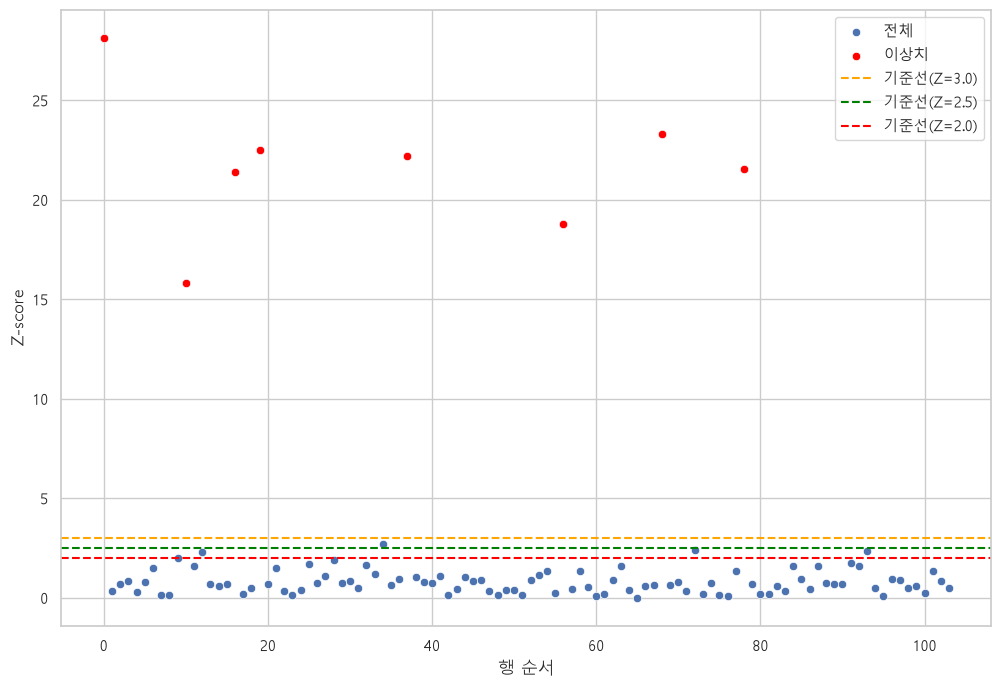

In [7]:
# 실습5 코드
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x=df.index, y='z_rms', label='전체')
sns.scatterplot(data=anomalies, x=anomalies.index, y='z_rms', color='red', label='이상치')
plt.axhline(y=threshold, color='orange', linestyle='--', label=f'기준선(Z={threshold})')
plt.axhline(y=2.5, color='green', linestyle='--', label='기준선(Z=2.5)')
plt.axhline(y=2.0, color='red', linestyle='--', label='기준선(Z=2.0)')
plt.xlabel('행 순서')
plt.ylabel('Z-score')
plt.legend()
plt.show()

## 실습 6. 다른 feature에도 Z-score 적용
### 목표
같은 방식을 다른 특징에도 적용해 이상치 개수를 비교
### 단계
- 다른 특징마다 정상 평균·표준편차로 Z를 계산
- 기준을 넘는 개수를 세기
- 특징별 탐지 개수를 비교
### 예상 결과
두 특징 모두 기준 3에서 이상치 8건

In [8]:
# 실습6 코드
other_features = ['spectral_centroid', 'zero_crossing_rate']

for col in other_features:
    mean_val = normal[col].mean()
    std_val = normal[col].std()
    z = np.abs((df[col] - mean_val) / std_val)
    count = (z > threshold).sum()
    print(f"{col}: 이상치 {count}건")

spectral_centroid: 이상치 8건
zero_crossing_rate: 이상치 8건


## 실습 7. Z-score 결과와 실제 label 비교
### 목표
Z-score 판정 결과를 실제 정답과 대조해 정탐·미탐·오탐을 세기
### 단계
- Z가 기준을 넘으면 이상으로 예측한 열 만들기
- 예측과 실제 정답을 짝지어 정탐·미탐·오탐 세기
- 셋의 균형으로 탐지 품질 확인
### 예상 결과
정탐 8·미탐 0·오탐 0으로 완벽 분리

In [9]:
# 실습7 코드
df['pred'] = (df['z_rms'] > threshold).astype(int)

tp = ((df['pred'] == 1) & (df['label'] == 1)).sum() # 정탐
fn = ((df['pred'] == 0) & (df['label'] == 1)).sum() # 미탐
fp = ((df['pred'] == 1) & (df['label'] == 0)).sum() # 오탐

print("정탐:", tp, "미탐:", fn, "오탐:", fp)

정탐: 8 미탐: 0 오탐: 0


## 실습 8. 임계값 바꿔 결과 비교
### 목표
기준값을 바꿔 가며 탐지 개수가 어떻게 변하는지 비교
### 단계
- 여러 기준값을 준비
- 각 기준마다 넘는 개수를 세기
- 기준이 낮을수록 많이 잡힘을 확인
### 예상 결과
기준 2는 13건, 2.5는 9건, 3은 8건


In [10]:
# 실습8 코드
thresholds = [2, 2.5, 3]
cols = ["rms", "spectral_centroid", "zero_crossing_rate"]

for c in cols:
    m, s = normal[c].mean(), normal[c].std()
    z = np.abs((df[c] - m) / s)
    for t in thresholds:
        count = (z > t).sum()
        print(f"{c} / 기준 {t}: 이상치 {count}건")
        print()

rms / 기준 2: 이상치 13건

rms / 기준 2.5: 이상치 9건

rms / 기준 3: 이상치 8건

spectral_centroid / 기준 2: 이상치 11건

spectral_centroid / 기준 2.5: 이상치 9건

spectral_centroid / 기준 3: 이상치 8건

zero_crossing_rate / 기준 2: 이상치 11건

zero_crossing_rate / 기준 2.5: 이상치 9건

zero_crossing_rate / 기준 3: 이상치 8건



## 실습 9. C-MAPSS 샘플로 Z-score 적용
### 목표
같은 Z-score 방법을 설비 센서 데이터에 적용
### 단계
- 초반 정상 구간을 기준으로 평균·표준편차 잡기
- 전체 회차의 센서 값을 Z로 변환
- Z가 큰 후반 상위 값을 확인
### 예상 결과
후반 Z 상위 세 값이 15.6·11.6·11.6으로 크게 벗어남


In [11]:
# 실습9 코드
cmapss = pd.read_csv("..\\Data\\25_cmapss_sample.csv", encoding='utf-8')

# 정상 이상 데이터 구분
normal = cmapss[cmapss["cycle"] <= 20]
abnormal = cmapss[cmapss['failure_soon'] == 1]
print("cmapss 컬럼명:", cmapss.columns)
print()
print(normal.head(10).to_markdown())
print()
print(abnormal.head(10).to_markdown())

cmapss 컬럼명: Index(['unit_id', 'cycle', 'sensor_2', 'RUL', 'failure_soon'], dtype='str')

|    |   unit_id |   cycle |   sensor_2 |   RUL |   failure_soon |
|---:|----------:|--------:|-----------:|------:|---------------:|
|  0 |         1 |       1 |     642.51 |    39 |              0 |
|  1 |         1 |       2 |     641.99 |    38 |              0 |
|  2 |         1 |       3 |     641.91 |    37 |              0 |
|  3 |         1 |       4 |     641.72 |    36 |              0 |
|  4 |         1 |       5 |     641.81 |    35 |              0 |
|  5 |         1 |       6 |     641.68 |    34 |              0 |
|  6 |         1 |       7 |     642.38 |    33 |              0 |
|  7 |         1 |       8 |     641.53 |    32 |              0 |
|  8 |         1 |       9 |     642.14 |    31 |              0 |
|  9 |         1 |      10 |     641.47 |    30 |              0 |

|    |   unit_id |   cycle |   sensor_2 |   RUL |   failure_soon |
|---:|----------:|--------:|-----------

In [12]:
cm_normal_mean = normal.mean()
cm_abnormal_mean = abnormal.mean()
cm_normal_std = normal.std()
cm_abnormal_std = abnormal.std()

print(cm_normal_mean,'\n', cm_abnormal_mean, '\n', cm_normal_std, '\n', cm_abnormal_std)

unit_id           1.0000
cycle            10.5000
sensor_2        642.0175
RUL              29.5000
failure_soon      0.0000
dtype: float64 
 unit_id           1.00000
cycle            36.50000
sensor_2        645.99875
RUL               3.50000
failure_soon      1.00000
dtype: float64 
 unit_id         0.000000
cycle           5.916080
sensor_2        0.380137
RUL             5.916080
failure_soon    0.000000
dtype: float64 
 unit_id         0.000000
cycle           2.449490
sensor_2        1.090995
RUL             2.449490
failure_soon    0.000000
dtype: float64


In [13]:
cmapss['z_sensor_2'] = abs((cmapss['sensor_2'] - cm_normal_mean.loc['sensor_2']) / cm_normal_std.loc['sensor_2'])  # sensor_2값 z-score 저장
print('후반 값 확인:\n', cmapss['z_sensor_2'].tail(10))

후반 값 확인:
 30     4.741715
31     7.503879
32     7.346041
33     7.004058
34     8.030005
35    11.607665
36    11.555052
37    11.555052
38    11.134151
39    15.553613
Name: z_sensor_2, dtype: float64


## 실습 10. 종합 이상 구간 정비 리포트
### 목표
탐지 결과를 정비 리포트로 정리해 우선 점검 대상을 뽑기
### 단계
- 이상치 비율을 계산
- 점검 대상·기준·탐지 건수를 리포트로 출력
- Z 상위 몇 건을 최우선 점검으로 정리
### 예상 결과
이상 8건(약 7.7퍼센트), Z 상위 3건이 최우선 점검


In [14]:
# 실습10 코드
total = len(df)
n_anomaly = len(anomalies)
ratio = n_anomaly / total * 100

print("=== 설비 이상탐지 정비 리포트 ===")
print(f"점검 대상: 전체 {total}건")
print(f"판정 기준: |Z| > {threshold}")
print(f"탐지된 이상: {n_anomaly}건 (전체의 {ratio:.1f}%)")

print("\n[최우선 점검 대상 Top 3]")
top3 = anomalies.sort_values('z_rms', ascending=False).head(3)
for idx, row in top3.iterrows():
    print(f"- 인덱스 {idx}: rms={row['rms']}, Z={row['z_rms']:.1f} → 즉시 점검 권장")


=== 설비 이상탐지 정비 리포트 ===
점검 대상: 전체 104건
판정 기준: |Z| > 3.0
탐지된 이상: 8건 (전체의 7.7%)

[최우선 점검 대상 Top 3]
- 인덱스 0: rms=0.6196, Z=28.1 → 즉시 점검 권장
- 인덱스 68: rms=0.5301, Z=23.3 → 즉시 점검 권장
- 인덱스 19: rms=0.5158, Z=22.5 → 즉시 점검 권장
